# Датасет без изменений

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_file_name = '/content/drive/MyDrive/Европейский университет/Выпускной проект/dataset.zip'

Mounted at /content/drive


In [ ]:
import zipfile

zip_file_name = '/content/drive/MyDrive/Европейский университет/Выпускной проект/dataset.zip'

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
labels_path = '/content/dataset┬áΓÇö ╨║╨╛╨┐╨╕╤Å/legs_positions_labels'
pics_path = '/content/dataset┬áΓÇö ╨║╨╛╨┐╨╕╤Å/legs_positions_pictures'

In [ ]:
class SkeletonDataset(Dataset):
    def __init__(self, images_root, coords_root, transform=None, point_transforms=None):
        self.images_root = images_root # пути к изображениям
        self.coords_root = coords_root # пути к координатам
        self.transform = transform # хранит переданные трансформации
        self.point_transforms = point_transforms # хранит переданные трансформации
        self.data = [] # сюда будут записаны пути к изображениям, файлы координат и метки классов
        self.class_to_idx = {} # словарь, сопоставляющий имя класса с индексом

        # Собираем все классы в словарь self.class_to_idx
        for class_name in sorted(os.listdir(images_root)):
            class_path = os.path.join(images_root, class_name)
            if os.path.isdir(class_path): # если элемент — папка,
                self.class_to_idx[class_name] = len(self.class_to_idx) # добавляем имя папки == имя класса в self.class_to_idx с индексом
        # Таким образом, каждому классу присваивается уникальный индекс (0, 1, 2 и т. д.).

        # Рекурсивно обходим папки с изображениями
        for root, _, files in os.walk(images_root):
            for file in files:
                if file.endswith(('.jpeg', '.png')):
                    # Получаем относительный путь к изображению
                    rel_path = os.path.relpath(os.path.join(root, file), images_root)
                    # Получаем путь к файлу с координатами
                    coord_path = os.path.join(coords_root, os.path.splitext(rel_path)[0] + '.txt')
                    # Проверяем, что соответствующий файл с координатами существует
                    if os.path.exists(coord_path):
                        image_path = os.path.join(images_root, rel_path)
                        # Извлекаем метку класса из имени подпапки
                        class_name = rel_path.split(os.sep)[0]
                        label = self.class_to_idx[class_name]
                        self.data.append((image_path, coord_path, label))

    def __len__(self):
        return len(self.data)

    # Загрузка элементов
    def __getitem__(self, idx):
        image_path, coords_path, label = self.data[idx] # получаем пути к изображениям и координатам
        image = Image.open(image_path).convert('RGB') # загружаем изображение и конвертируем сразу в RGB

        # Применяем трансформации к картинкам, если self.transform = True
        if self.transform:
            image = self.transform(image)

        # Загружаем координаты в виде масива numpy
        with open(coords_path, 'r') as f:
            coords = np.loadtxt(f)

        # ширина и высота скелета (разница между максимальным и минимальным значением по осям X и Y)
        width = coords[0,:].max() - coords[0,:].min()
        height = coords[1,:].max() - coords[1,:].min()

        # средние значения координат (центр скелета)
        cx = coords[0,:].mean()
        cy = coords[1,:].mean()

        # ОЛЕГ: Стоит нормализировать исходя из размеров самого скелетона
        coords[:, 0] = (coords[:, 0] - cx) / width  # нормализация широты
        coords[:, 1] = (coords[:, 1] - cy) / height  # нормализация высоты

        # Обрезаем значения в пределах [0, 1]
        coords = np.clip(coords, 0, 1)

        # Преобразуем координаты скелетона в тензор
        coords = torch.tensor(coords, dtype=torch.float32)

        # Если переданы специальные трансформации для координат (point_transforms), применяем их (при transformations = True)
        if self.point_transforms is not None:
            coords = self.point_transforms(coords)

        label = torch.tensor(label, dtype=torch.long) # превращаем метку класса в тензор

        return image, coords, label # получаем тензоры

In [ ]:
# transforms.Compose([...]) объединяет несколько преобразований в один пайплайн
transform = transforms.Compose([
    transforms.Resize((256, 256)), # изменяет изображения в меньший формат
    transforms.ToTensor(), # конвертирует изображение из формата PIL или NumPy в тензор PyTorch с диапазоном значений [0, 1] и порядком каналов (C, H, W)
])

In [ ]:
dataset = SkeletonDataset(images_root=pics_path,
                          coords_root=labels_path,
                          transform=transform) # передаем трансформацию для изображений

In [ ]:
dataloader = torch.utils.data.DataLoader(dataset,
                                         batch_size=32,
                                         shuffle=True) # перемешиваем

In [ ]:
# Итерация по dataloader возвращает images, coords и labels для одного батча
for images, coords, labels in dataloader:
    print("Размер изображений:", images.shape)  # размер тензора (batch_size, число цветовых каналов (RGB), 256, 256). последнее - размер изображения
    print("Размер координат:", coords.shape)    # (batch_size, num_nodes, 2). num_nodes — количество ключевых точек скелета, 2 - координаты x,y
    print("Размер меток:", labels.shape)         # (batch_size,) - размер меток классов, 32 (по одной метке на изображение)
    print("Пример меток:", labels[:5])           # Вывод первых 5 меток
    break

Размер изображений: torch.Size([32, 3, 256, 256])
Размер координат: torch.Size([32, 17, 3])
Размер меток: torch.Size([32])
Пример меток: tensor([10,  6, 26,  0,  7])


In [ ]:
# # класс PointCoordsRandomTransform выполняет случайные трансформации координат точек (аугментацию)
# class PointCoordsRandomTransform:
#     def __init__(self, p_rot=0.5, # вероятность применения поворота
#                  rot_range_deg=(-10, 10), # диапазон углов поворота в градусах
#                  p_shift=0.5, # вероятность применения сдвига
#                  shift=20, # максимальное значение сдвига по x и y
#                  p_scale_x=0.5, # вероятность масштабирования по x
#                  scale_x=(0.8, 1.2), # диапазон коэффициентов масштабирования по x
#                  p_scale_y=0.5, # вероятность масштабирования по y
#                  scale_y=(0.8, 1.2)): # диапазон коэффициентов масштабирования по y

#         # сохраняем параметры
#         self.p_rot = p_rot
#         self.rot_range_deg = rot_range_deg
#         self.p_shift = p_shift
#         self.shift = shift
#         self.p_scale_x = p_scale_x
#         self.scale_x = scale_x
#         self.p_scale_y = p_scale_y
#         self.scale_y = scale_y

#     # применение трансформации
#     def __call__(self, coords):
#         coords = coords.clone()  # Создаем копию тензора, чтобы избежать изменения оригинального тензора

#         # Разделяем x, y и conf
#         xy = coords[:, :2]  # только координаты x, y
#         conf = coords[:, -1:]  # только уверенность модели

#         # С вероятностью p_rot выполняем поворот
#         if np.random.rand() < self.p_rot:
#             angle = np.random.uniform(*self.rot_range_deg) # выбираем случайный угол поворота в заданном диапазоне (rot_range_deg)
#             angle = np.deg2rad(angle) # переводим угол из градусов в радианы
#             # Создаем матрицу поворота
#             rot_mat = torch.tensor([[np.cos(angle), -np.sin(angle)],
#                                     [np.sin(angle),  np.cos(angle)]], dtype=torch.float32)
#             xy = xy @ rot_mat.T  # применяем поворот

#         # С вероятностью p_shift выполняем случайный сдвиг
#         if np.random.rand() < self.p_shift:
#             # генерируем случайное смещение в диапазоне [-shift, shift] для x и y
#             shift_val = torch.tensor(np.random.uniform(-self.shift, self.shift, size=(2,)), dtype=torch.float32)
#             xy += shift_val # прибавляем shift_val к координатам точек

#         # С вероятностью p_scale_x случайно изменяем масштаб по x (умножаем на случайное число из scale_x)
#         if np.random.rand() < self.p_scale_x:
#             xy[:, 0] *= np.random.uniform(*self.scale_x)

#         # Аналогично масштабируем y с вероятностью p_scale_y
#         if np.random.rand() < self.p_scale_y:
#             xy[:, 1] *= np.random.uniform(*self.scale_y)

#         transformed_coords = torch.cat([xy, conf], dim=1)  # склеиваем обратно x, y и conf

#         return transformed_coords

In [ ]:
# transform = PointCoordsRandomTransform()

# # собираем данные в numpy массивы
# X, y = [], []
# for epoch in range(10): # увеличиваем датасет в 10 раз == 10 эпох
#     for _, coords, label in dataset: # пропускаем изображение и смотрим только координаты и метки
#         # оригинальные координаты
#         X.append(coords.view(-1).numpy()) # coords.view(-1) превращает координаты в одномерный тензор
#         y.append(label.item()) # превращает тензор-метку в обычное число

#         # преображение координат
#         transformed_coords = transform(coords)
#         X.append(transformed_coords.view(-1).numpy())
#         y.append(label.item())

# # Превращаем списки X и y в массивы numpy для удобства работы
# X = np.array(X)
# y = np.array(y)

In [ ]:
# print(len(X))
# print(X.shape)
# print(len(y))
# print(y.shape)

39100
(39100, 51)
39100
(39100,)


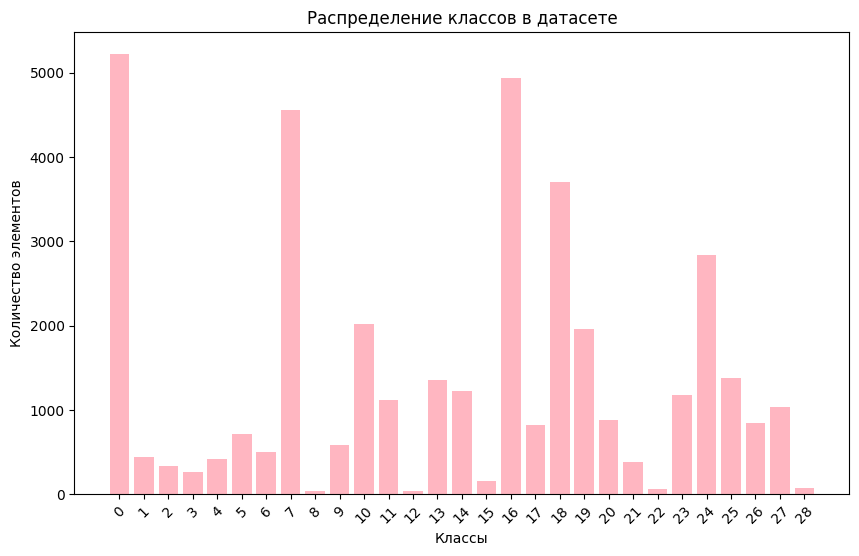

In [ ]:
# import matplotlib.pyplot as plt
# from collections import Counter

# # Подсчитываем количество каждого класса
# class_counts = Counter(y)

# # Преобразуем классы и их количество в списки
# classes = list(class_counts.keys())
# counts = list(class_counts.values())

# # Строим график
# plt.figure(figsize=(10, 6))
# plt.bar(classes, counts, color='lightpink')
# plt.xlabel('Классы')
# plt.ylabel('Количество элементов')
# plt.title('Распределение классов в датасете')
# plt.xticks(classes, rotation=45)
# plt.show()

In [ ]:
# import random
# from tqdm import tqdm

# max_elements_in_class = 5220
# names = np.unique(y)  # 29
# X_new = []
# Y_new = []
# for n in tqdm(names):
#     x_n = X[y==n]
#     print(len(x_n))
#     for x in tqdm(x_n):
#         X_new.append(x)
#         Y_new.append(n)

#     # while len(x_n) < max_elements_in_class:
#     for i in range(max_elements_in_class - len(x_n)):
#         # print(len(X_new))
#         random_index = random.randint(0, len(x_n) - 1)  # Выбираем случайный индекс
#         X_new.append(x_n[random_index])  # Берем всю строку (точку) по этому индексу
#         Y_new.append(n)
#     print(len(x_n))

  0%|          | 0/29 [00:00<?, ?it/s]

5220



100%|██████████| 5220/5220 [00:00<00:00, 458058.22it/s]


5220
440



100%|██████████| 440/440 [00:00<00:00, 782652.15it/s]


...

840
1040



100%|██████████| 1040/1040 [00:00<00:00, 1073345.51it/s]


1040
80



100%|██████████| 29/29 [00:01<00:00, 25.56it/s]

80


In [ ]:
# np.unique(Y_new)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [ ]:
# import pandas as pd

# df = pd.DataFrame(Y_new, columns=['y_new'])

In [ ]:
# print(X.shape)
# X_new = np.array(X_new)
# print(X_new.shape)

(39100, 51)
(151380, 51)


In [ ]:
# print(y.shape)
# Y_new = np.array(Y_new)
# print(Y_new.shape)

(39100,)
(151380,)


In [ ]:
# from collections import Counter
# from pprint import pprint

# class_counts = Counter(Y_new)
# pprint(class_counts)

Counter({0: 5220,
         1: 5220,
         2: 5220,
         3: 5220,
         4: 5220,
         5: 5220,
         6: 5220,
         7: 5220,
         8: 5220,
         9: 5220,
         10: 5220,
         11: 5220,
         12: 5220,
         13: 5220,
         14: 5220,
         15: 5220,
         16: 5220,
         17: 5220,
         18: 5220,
         19: 5220,
         20: 5220,
         21: 5220,
         22: 5220,
         23: 5220,
         24: 5220,
         25: 5220,
         26: 5220,
         27: 5220,
         28: 5220})


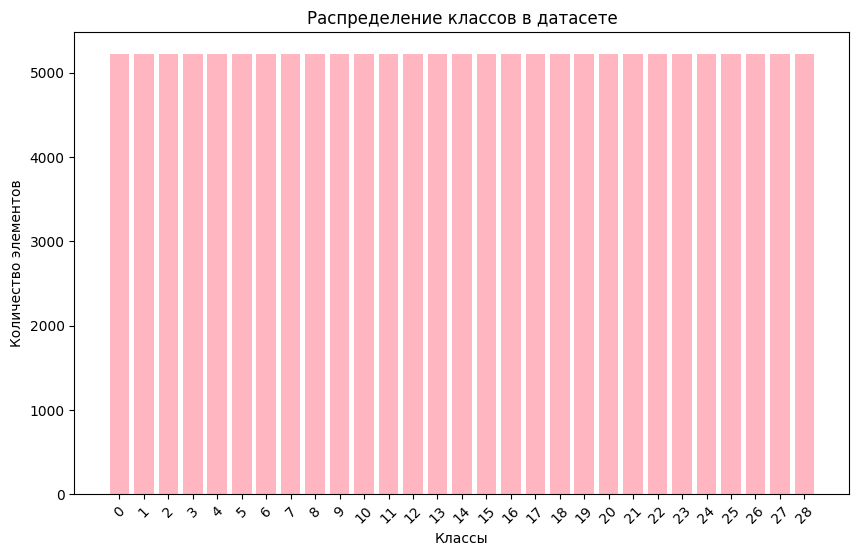

In [ ]:
# import matplotlib.pyplot as plt
# from collections import Counter

# # Подсчитываем количество каждого класса
# class_counts_new = Counter(Y_new)

# # Преобразуем классы и их количество в списки
# classes_new = list(class_counts_new.keys())
# counts_new = list(class_counts_new.values())

# # Строим график
# plt.figure(figsize=(10, 6))
# plt.bar(classes_new, counts_new, color='lightpink')
# plt.xlabel('Классы')
# plt.ylabel('Количество элементов')
# plt.title('Распределение классов в датасете')
# plt.xticks(classes_new, rotation=45)
# plt.show()

In [ ]:
# # # Превращаем в numpy массивы
# X_new = np.array(X_new)
# Y_new = np.array(Y_new)

In [ ]:
from sklearn.model_selection import train_test_split

# Собираем все данные в numpy массивы
X, y = [], []

for _, coords, label in dataset:
    X.append(coords.view(-1).numpy())  # Выпрямляем координаты в вектор
    y.append(label.item())

X = np.array(X)
y = np.array(y)

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размеры данных:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Размеры данных:
X_train: (1564, 51)
X_test: (391, 51)
y_train: (1564,)
y_test: (391,)


### Пробуем обучить DecisionTreeClassifier

In [ ]:
# копируем датасеты для обучения модели
X_train_DecTree, X_test_DecTree, y_train_DecTree, y_test_DecTree = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
# Инициализация и обучение модели
clf_DecTree = DecisionTreeClassifier(random_state=42) # random_state=42 фиксирует случайность (чтобы результаты были одинаковыми при каждом запуске)
clf_DecTree.fit(X_train_DecTree, y_train_DecTree) # обучаем модель на тренировочных данных

DecisionTreeClassifier(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_DecTree = clf_DecTree.predict(X_test_DecTree) # результаты сохраняем в y_pred_DecTree

In [ ]:
# Оценка точности
accuracy_DecTree = accuracy_score(y_test_DecTree, y_pred_DecTree) # доля правильно предсказанных примеров
print(f"Точность на тестовой выборке: {accuracy_DecTree:.2f}")

Точность на тестовой выборке: 0.41


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_DecTree, y_pred_DecTree))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.51      0.46      0.49        56
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.33      0.25      0.29         4
           4       0.50      0.29      0.36         7
           5       0.29      0.20      0.24        10
           6       0.33      0.40      0.36         5
           7       0.47      0.44      0.46        54
           9       0.00      0.00      0.00         7
          10       0.48      0.52      0.50        27
          11       0.18      0.33      0.24         6
          13       0.25      0.23      0.24        13
          14       0.07      0.10      0.08        10
          15       0.00      0.00      0.00         2
          16       0.52      0.59      0.55        39
          17       0.11      0.10      0.11        10
          18       0.69      0.73      0.71        33
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
# Матрица ошибок
conf_matrix_DecTree = confusion_matrix(y_test_DecTree, y_pred_DecTree)
print("Матрица ошибок:")
print(conf_matrix_DecTree)

Матрица ошибок:
[[26  0  0  0  0  1  0 14  0  0  0  0  2  0  5  0  2  0  1  1  0  1  0  1
   1  1  0]
 [ 0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  1
   0  0  0]
 [ 0  0  0  1  0  0  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  1  1  0
   0  0  0]
 [ 0  0  0  1  1  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  1  0
   0  0  0]
 [ 1  0  0  0  2  0  0  1  0  0  0  0  0  0  2  1  0  0  0  0  0  0  0  0
   0  0  0]
 [ 0  0  2  0  0  2  1  0  0  2  0  0  0  0  0  1  0  0  0  1  0  0  0  1
   0  0  0]
 [ 0  0  1  0  0  1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0
   0  0  0]
 [19  2  0  0  0  0  0 24  0  0  0  3  0  0  2  0  1  0  1  0  0  1  1  0
   0  0  0]
 [ 0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  0  0  0  0  1  0
   0  4  0]
 [ 0  0  0  0  0  0  0  0  0 14  3  1  1  0  0  0  1  0  0  2  0  1  3  0
   1  0  0]
 [ 0  0  0  0  0  0  0  0  0  3  2  0  0  0  0  0  0  0  0  0  0  0  1  0
   0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  3 

In [ ]:
# Точность модели на тестовых данных
accuracy_DecTree_test = accuracy_score(y_test_DecTree, y_pred_DecTree)
print(f"Точность на тестовой выборке: {accuracy_DecTree_test:.2f}")

Точность на тестовой выборке: 0.41


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_DecTree, y_pred_DecTree))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.51      0.46      0.49        56
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.33      0.25      0.29         4
           4       0.50      0.29      0.36         7
           5       0.29      0.20      0.24        10
           6       0.33      0.40      0.36         5
           7       0.47      0.44      0.46        54
           9       0.00      0.00      0.00         7
          10       0.48      0.52      0.50        27
          11       0.18      0.33      0.24         6
          13       0.25      0.23      0.24        13
          14       0.07      0.10      0.08        10
          15       0.00      0.00      0.00         2
          16       0.52      0.59      0.55        39
          17       0.11      0.10      0.11        10
          18       0.69      0.73      0.71        33
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

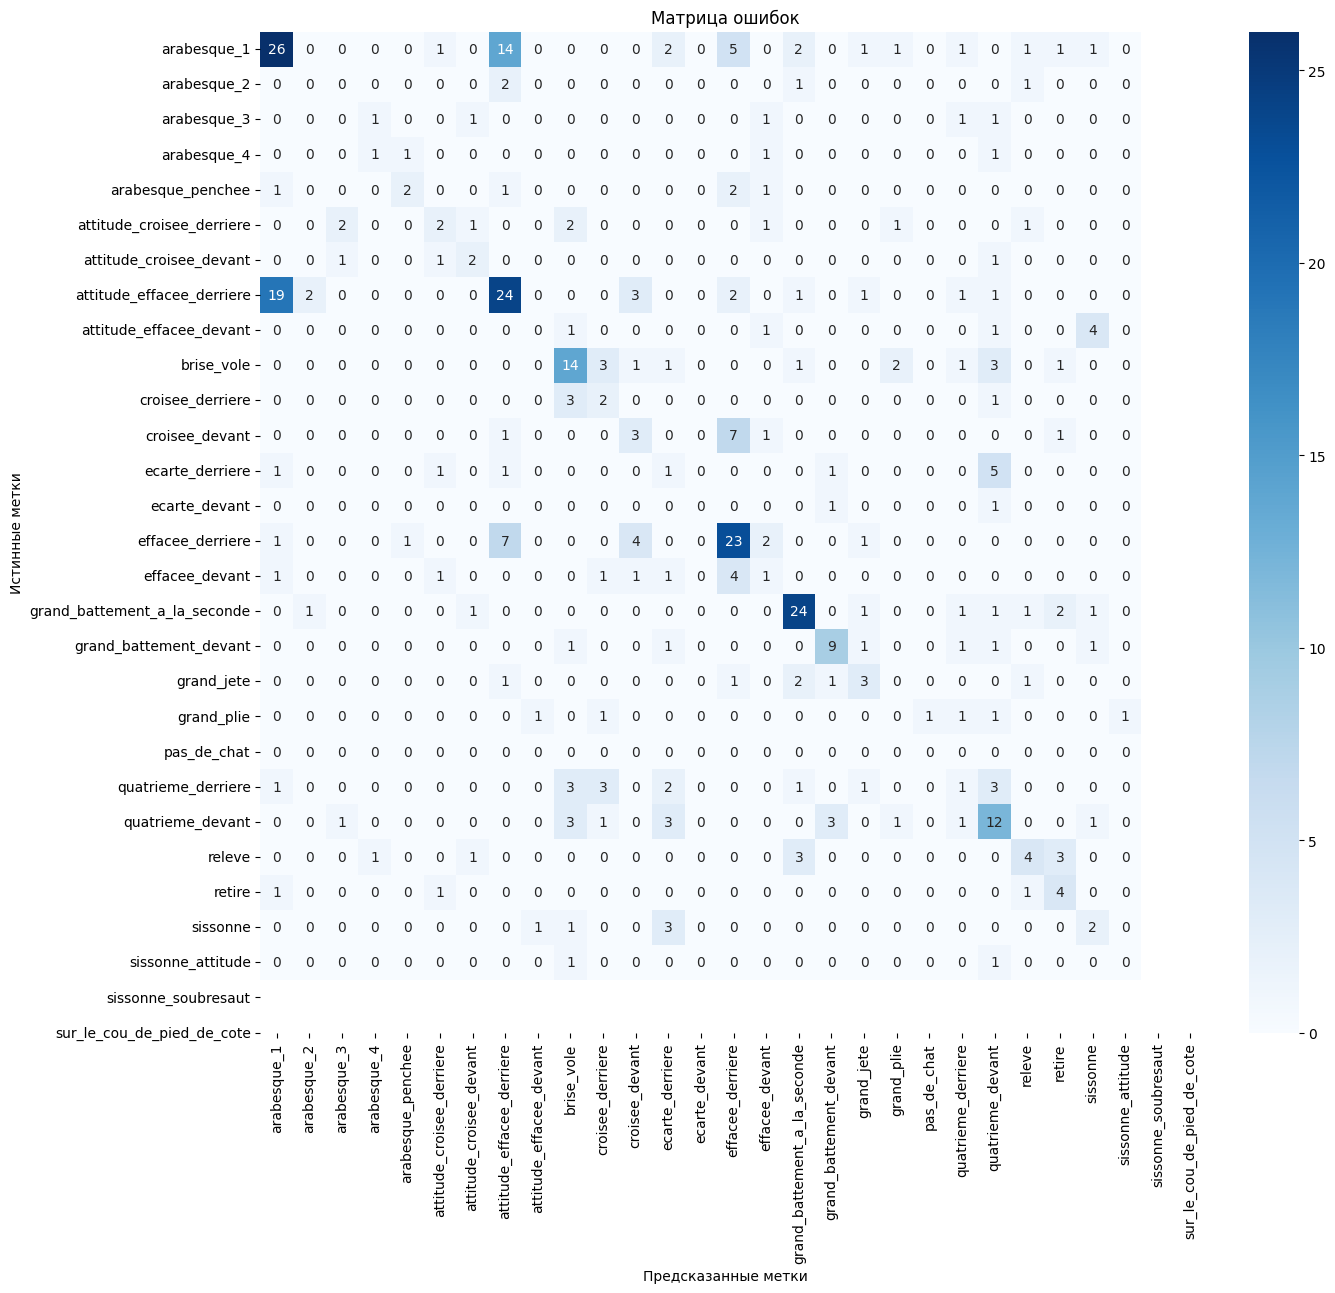

In [ ]:
from sklearn.metrics import confusion_matrix

# Матрица ошибок
conf_matrix_DecTree = confusion_matrix(y_test_DecTree, y_pred_DecTree)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_DecTree, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

In [ ]:
clf_DecTree.fit(X_train_DecTree, y_train_DecTree)

DecisionTreeClassifier(random_state=42)

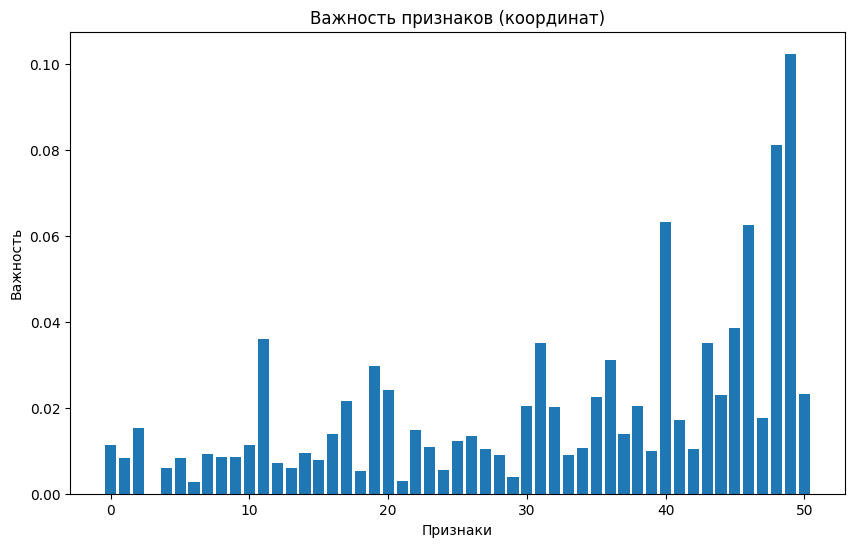

In [ ]:
# Визуализация важности признаков
feature_importance_DecTree = clf_DecTree.feature_importances_

# ОТКУДА ЭТИ ПРИЗНАКИ? КАК ПОНЯТЬ, ЧТО МОДЕЛЬ ОЦЕНИВАЕТ?

# Отображаем важность признаков
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importance_DecTree)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков (координат)')
plt.show()

In [ ]:
# import joblib

# # Сохраняем модель в файл
# model_filename = 'skeleton_classifier.pkl'
# joblib.dump(clf, model_filename)

# print(f"Модель сохранена в файле: {model_filename}")

Когда нужно использовать модель для предсказаний на новых данных:

In [ ]:
# # Загружаем модель из файла
# loaded_model = joblib.load(model_filename)

# # Проверка работы загруженной модели
# y_pred = loaded_model.predict(X_test)
# print("Точность загруженной модели:", accuracy_score(y_test, y_pred))

Визуализация дерева решений:

Деревья решений легко интерпретировать, поэтому полезно их визуализировать.

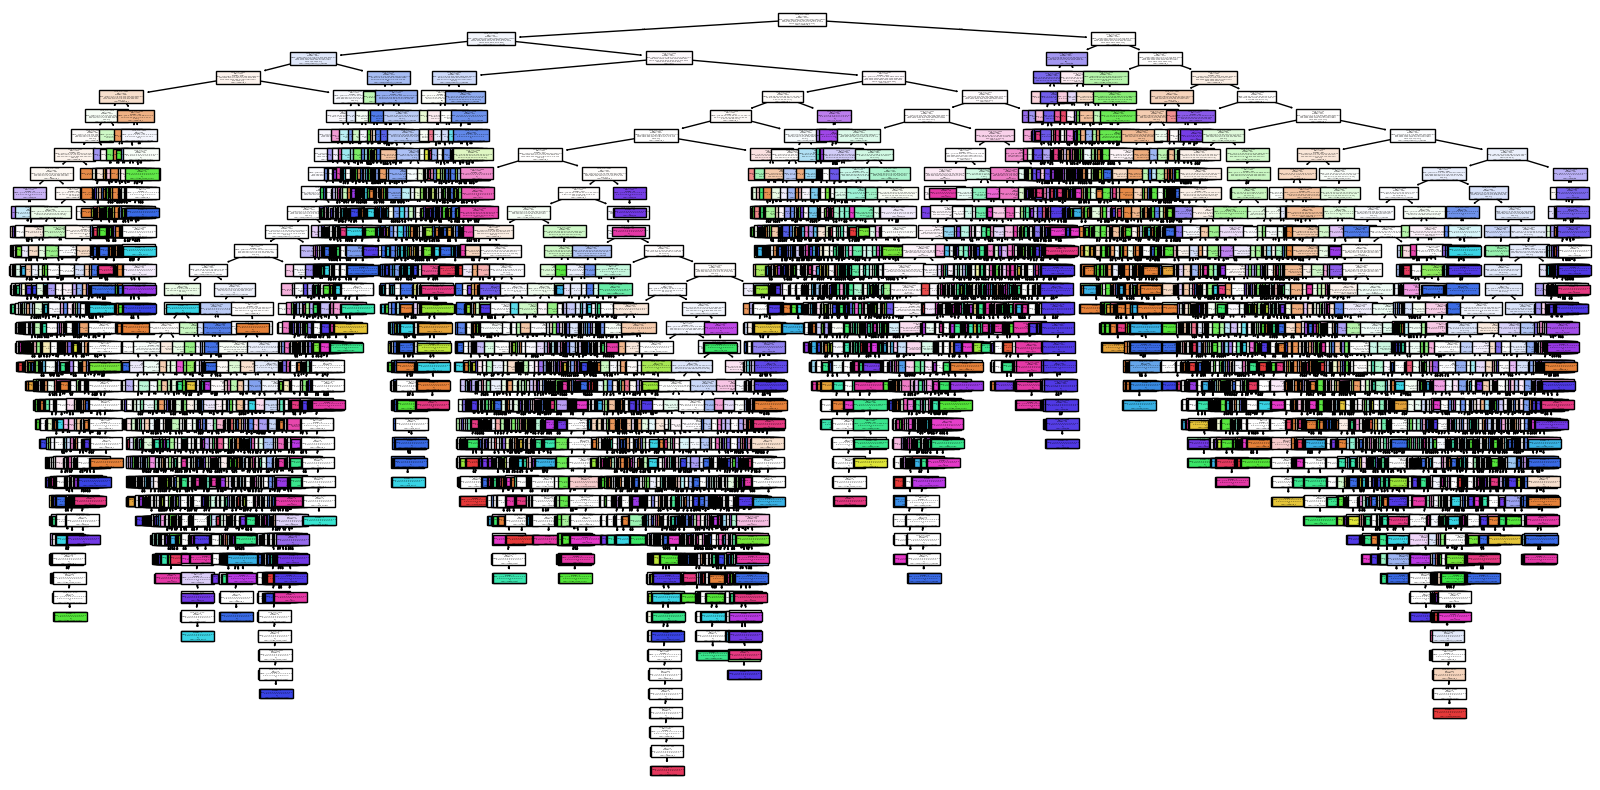

In [ ]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_DecTree,
               feature_names=[f"coord_{i}" for i in range(X.shape[1])],
               class_names=[str(c) for c in dataset.class_to_idx.keys()],
               filled=True)
plt.show()

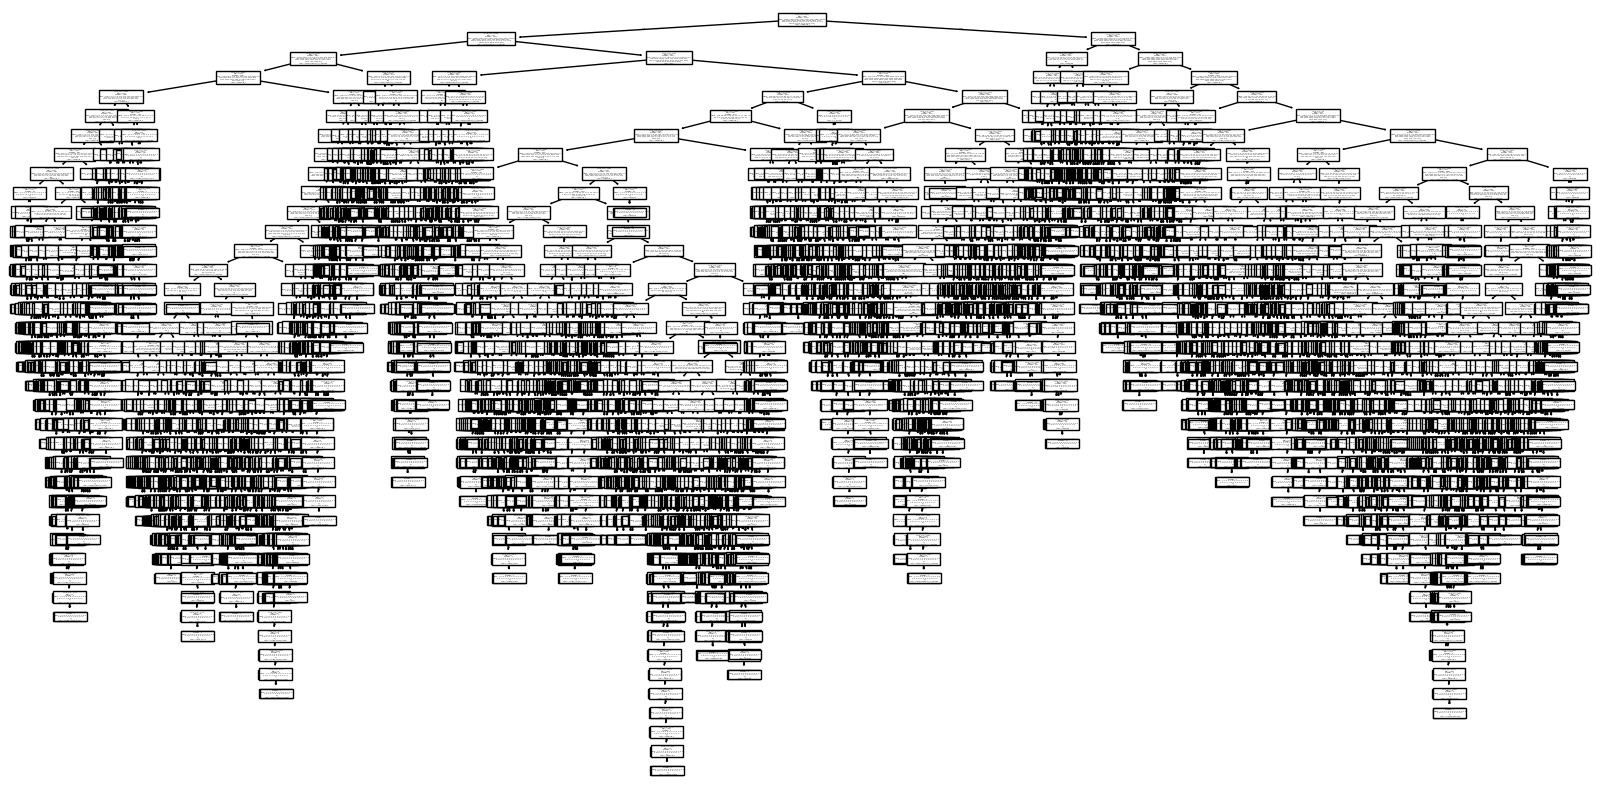

In [ ]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_DecTree,
               feature_names=[f"coord_{i}" for i in range(X.shape[1])],
               class_names=[str(c) for c in dataset.class_to_idx.keys()],
               filled=False)
plt.show()

### Пробуем обучить SVC

In [ ]:
# копируем датасеты для обучения модели
X_train_SVC, X_test_SVC, y_train_SVC, y_test_SVC = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.svm import SVC

# Инициализация и обучение модели
clf_SVC = SVC(kernel='rbf', random_state=42)
clf_SVC.fit(X_train_SVC, y_train_SVC)

SVC(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_SVC = clf_SVC.predict(X_test_SVC)

In [ ]:
# Оценка точности
accuracy_SVC = accuracy_score(y_test_SVC, y_pred_SVC)
print(f"Точность на тестовой выборке: {accuracy_SVC:.2f}")

Точность на тестовой выборке: 0.51


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_SVC, y_pred_SVC))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.58      0.66      0.62        56
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         7
           5       0.18      0.20      0.19        10
           6       0.00      0.00      0.00         5
           7       0.54      0.57      0.56        54
           9       0.00      0.00      0.00         7
          10       0.40      0.81      0.54        27
          11       0.00      0.00      0.00         6
          13       0.00      0.00      0.00        13
          14       0.17      0.10      0.12        10
          15       0.00      0.00      0.00         2
          16       0.52      0.79      0.63        39
          17       0.60      0.30      0.40        10
          18       0.57      0.97      0.72        33
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Матрица ошибок
conf_matrix_SVC = confusion_matrix(y_test_SVC, y_pred_SVC)
print("Матрица ошибок:")
print(conf_matrix_SVC)

Матрица ошибок:
[[37  0  0  0  0  1  0 10  0  1  0  0  3  0  1  0  2  0  0  0  0  1  0  0
   0  0]
 [ 0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  2  0  0  0  1  0  0  0  0  0  1  1  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  3  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  3  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  2  0  0  0  5  0  0  0  0  1  0  1  0  0  0  0  1  0  0
   0  0]
 [ 0  0  0  0  0  1  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  1  0  0
   0  0]
 [14  0  0  0  0  0  0 31  0  0  0  0  0  0  7  0  1  0  0  0  0  1  0  0
   0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  6  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  1  0  0  0  4  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  2  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 12  1  0  0  0  0  0  0  0 

In [ ]:
# Точность модели на тестовых данных
accuracy_SVC_test = accuracy_score(y_test_SVC, y_pred_SVC)
print(f"Точность на тестовой выборке: {accuracy_SVC_test:.2f}")

Точность на тестовой выборке: 0.51


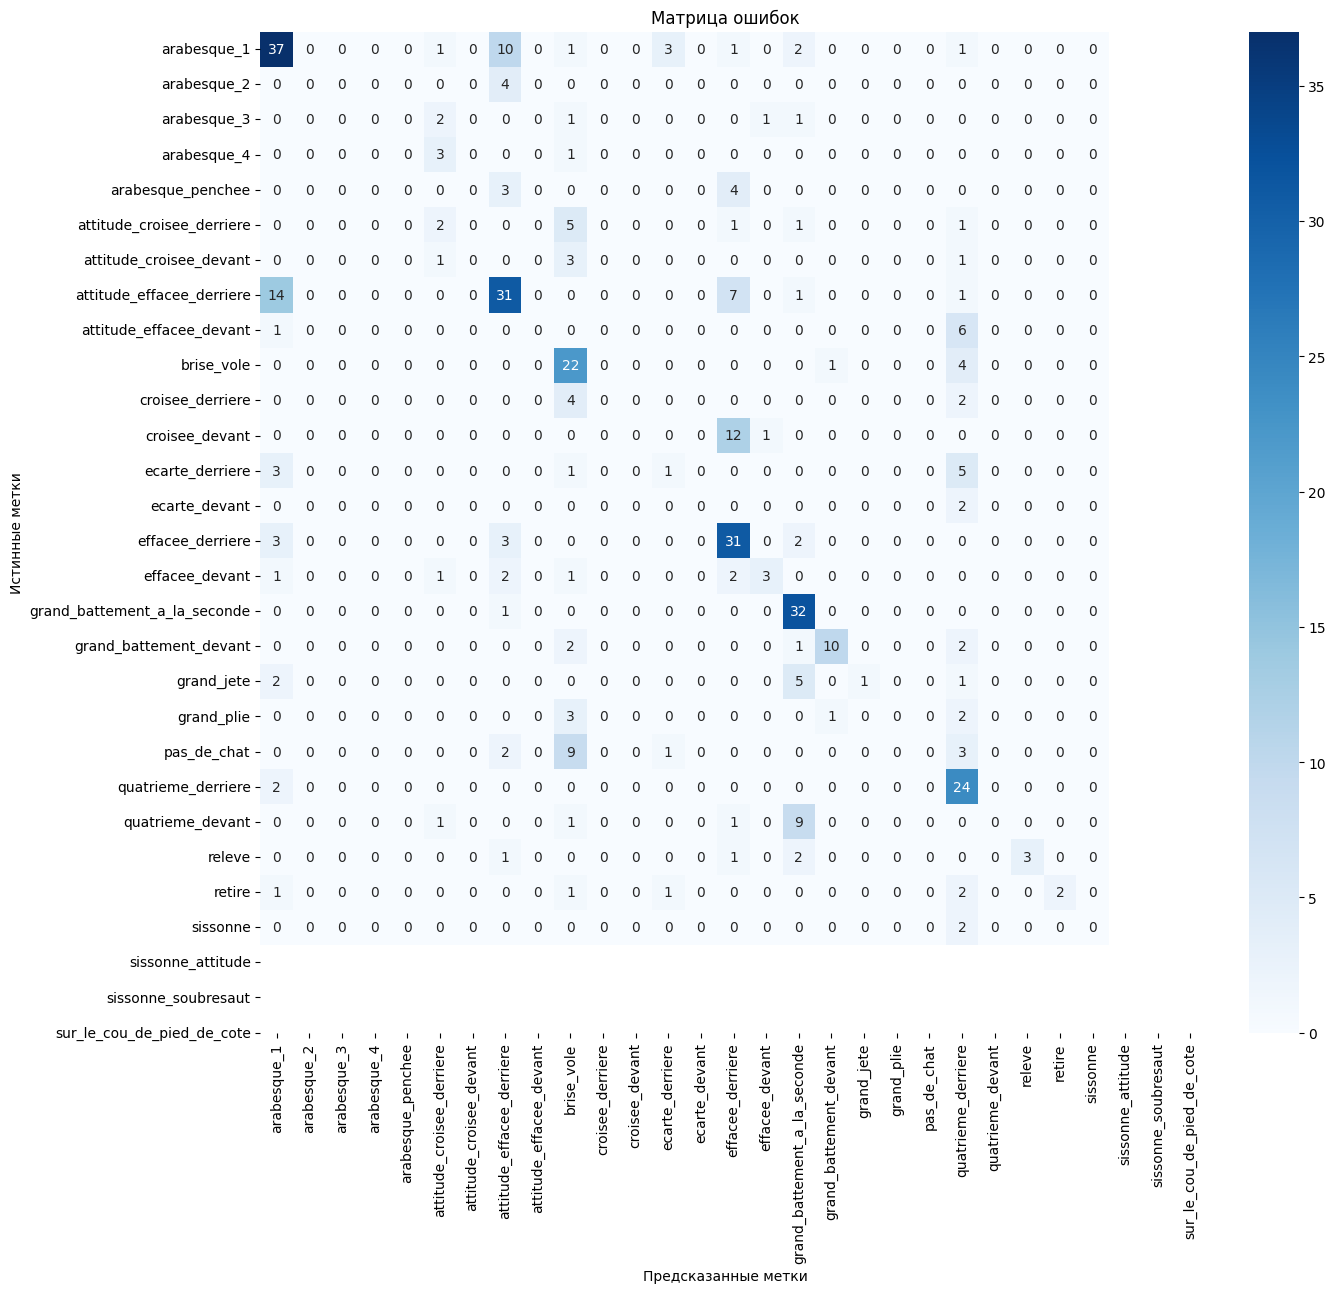

In [ ]:
# Матрица ошибок
conf_matrix_SVC = confusion_matrix(y_test_SVC, y_pred_SVC)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_SVC, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Пробуем обучить RandomForestClassifier

In [ ]:
X_train_RandFor, X_test_RandFor, y_train_RandFor, y_test_RandFor = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Инициализация и обучение модели
clf_RandFor = RandomForestClassifier(random_state=42)
clf_RandFor.fit(X_train_RandFor, y_train_RandFor)

RandomForestClassifier(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_RandFor = clf_RandFor.predict(X_test_RandFor)

In [ ]:
# Оценка точности
accuracy_RandFor = accuracy_score(y_test_RandFor, y_pred_RandFor)
print(f"Точность на тестовой выборке: {accuracy_RandFor:.2f}")

Точность на тестовой выборке: 0.57


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_RandFor, y_pred_RandFor))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68        56
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.50      0.25      0.33         4
           4       1.00      0.14      0.25         7
           5       0.29      0.20      0.24        10
           6       1.00      0.60      0.75         5
           7       0.61      0.72      0.66        54
           9       1.00      0.29      0.44         7
          10       0.54      0.70      0.61        27
          11       0.09      0.17      0.12         6
          13       1.00      0.08      0.14        13
          14       0.22      0.20      0.21        10
          15       0.00      0.00      0.00         2
          16       0.56      0.90      0.69        39
          17       0.25      0.10      0.14        10
          18       0.75      1.00      0.86        33
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Матрица ошибок
conf_matrix_RandFor = confusion_matrix(y_test_RandFor, y_pred_RandFor)
# print("Матрица ошибок:")
# print(conf_matrix_RandFor)

In [ ]:
# Точность модели на тестовых данных
accuracy_RandFor_test = accuracy_score(y_test_RandFor, y_pred_RandFor)
print(f"Точность на тестовой выборке: {accuracy_RandFor_test:.2f}")

Точность на тестовой выборке: 0.57


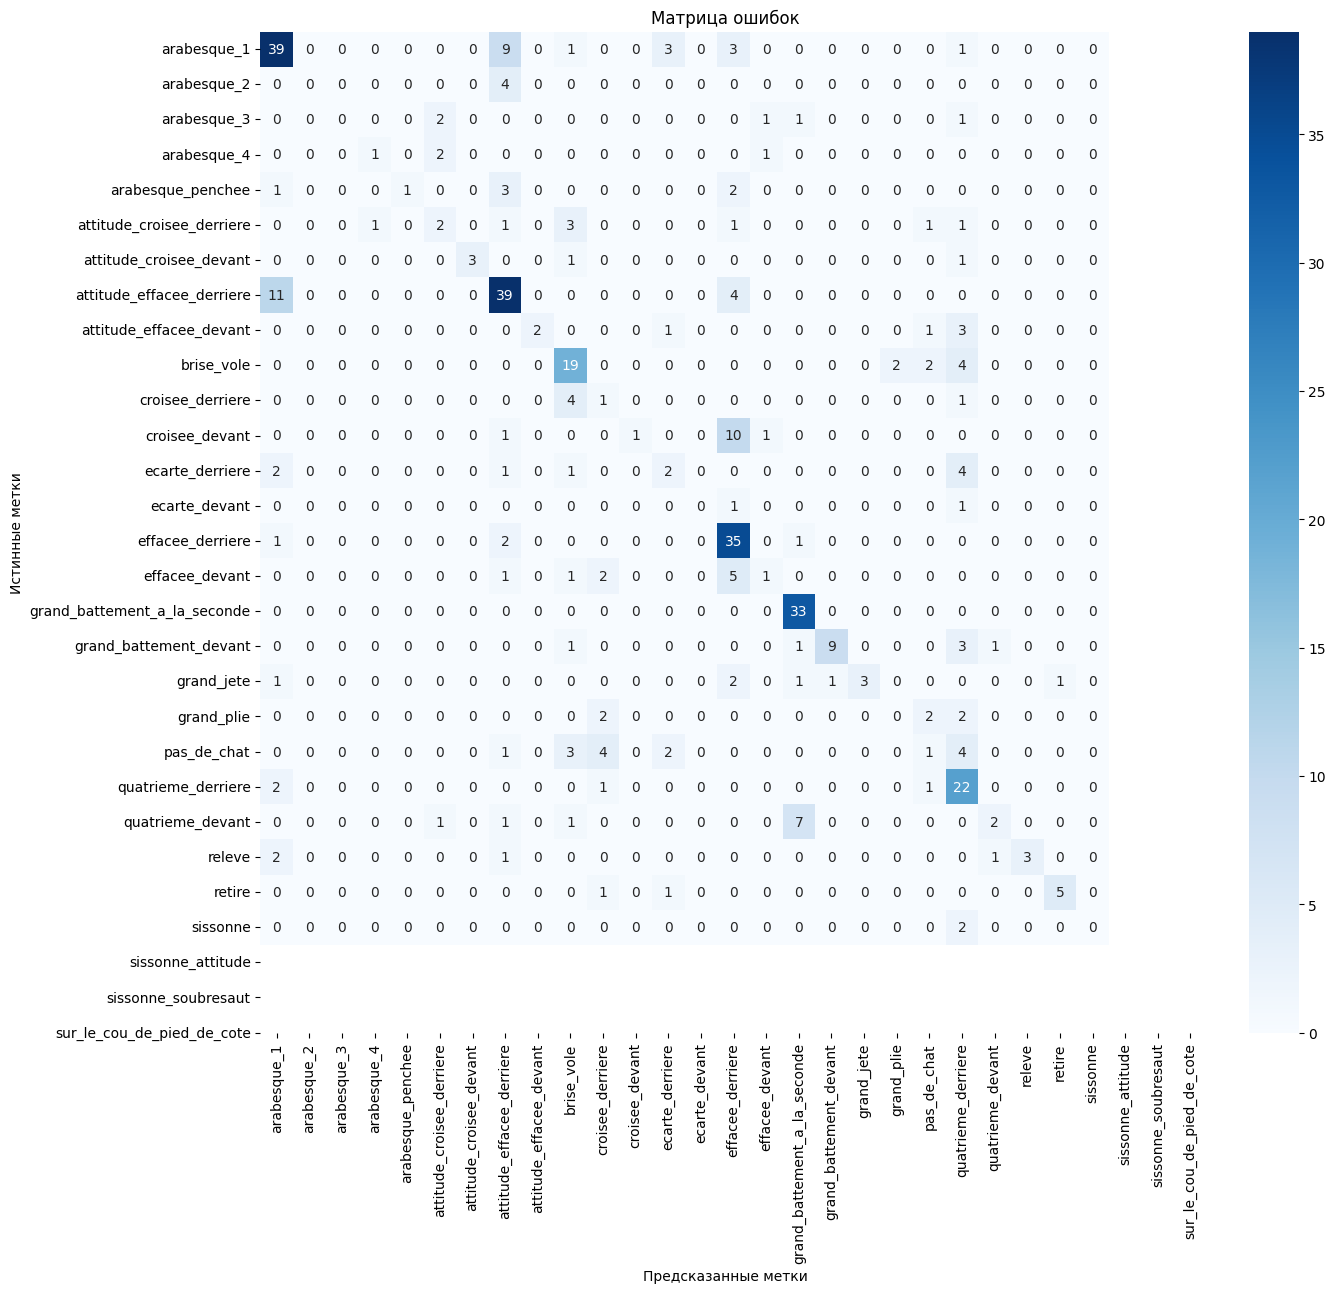

In [ ]:
# Матрица ошибок
conf_matrix_RandFor = confusion_matrix(y_test_RandFor, y_pred_RandFor)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_RandFor, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить AdaBoostClassifier

In [ ]:
X_train_AdaBo, X_test_AdaBo, y_train_AdaBo, y_test_AdaBo = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Инициализация и обучение модели
clf_AdaBo = AdaBoostClassifier(random_state=42)
clf_AdaBo.fit(X_train_AdaBo, y_train_AdaBo)

AdaBoostClassifier(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_AdaBo = clf_AdaBo.predict(X_test_AdaBo)

In [ ]:
# Оценка точности
accuracy_AdaBo = accuracy_score(y_test_AdaBo, y_pred_AdaBo)
print(f"Точность на тестовой выборке: {accuracy_AdaBo:.2f}")

Точность на тестовой выборке: 0.22


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_AdaBo, y_pred_AdaBo))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.16      0.39      0.23        56
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00         5
           7       0.21      0.48      0.29        54
           9       0.00      0.00      0.00         7
          10       0.46      0.41      0.43        27
          11       0.00      0.00      0.00         6
          13       0.00      0.00      0.00        13
          14       0.00      0.00      0.00        10
          15       0.00      0.00      0.00         2
          16       0.34      0.51      0.41        39
          17       0.00      0.00      0.00        10
          18       0.00      0.00      0.00        33
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Матрица ошибок
conf_matrix_AdaBo = confusion_matrix(y_test_AdaBo, y_pred_AdaBo)
# print("Матрица ошибок:")
# print(conf_matrix_AdaBo)

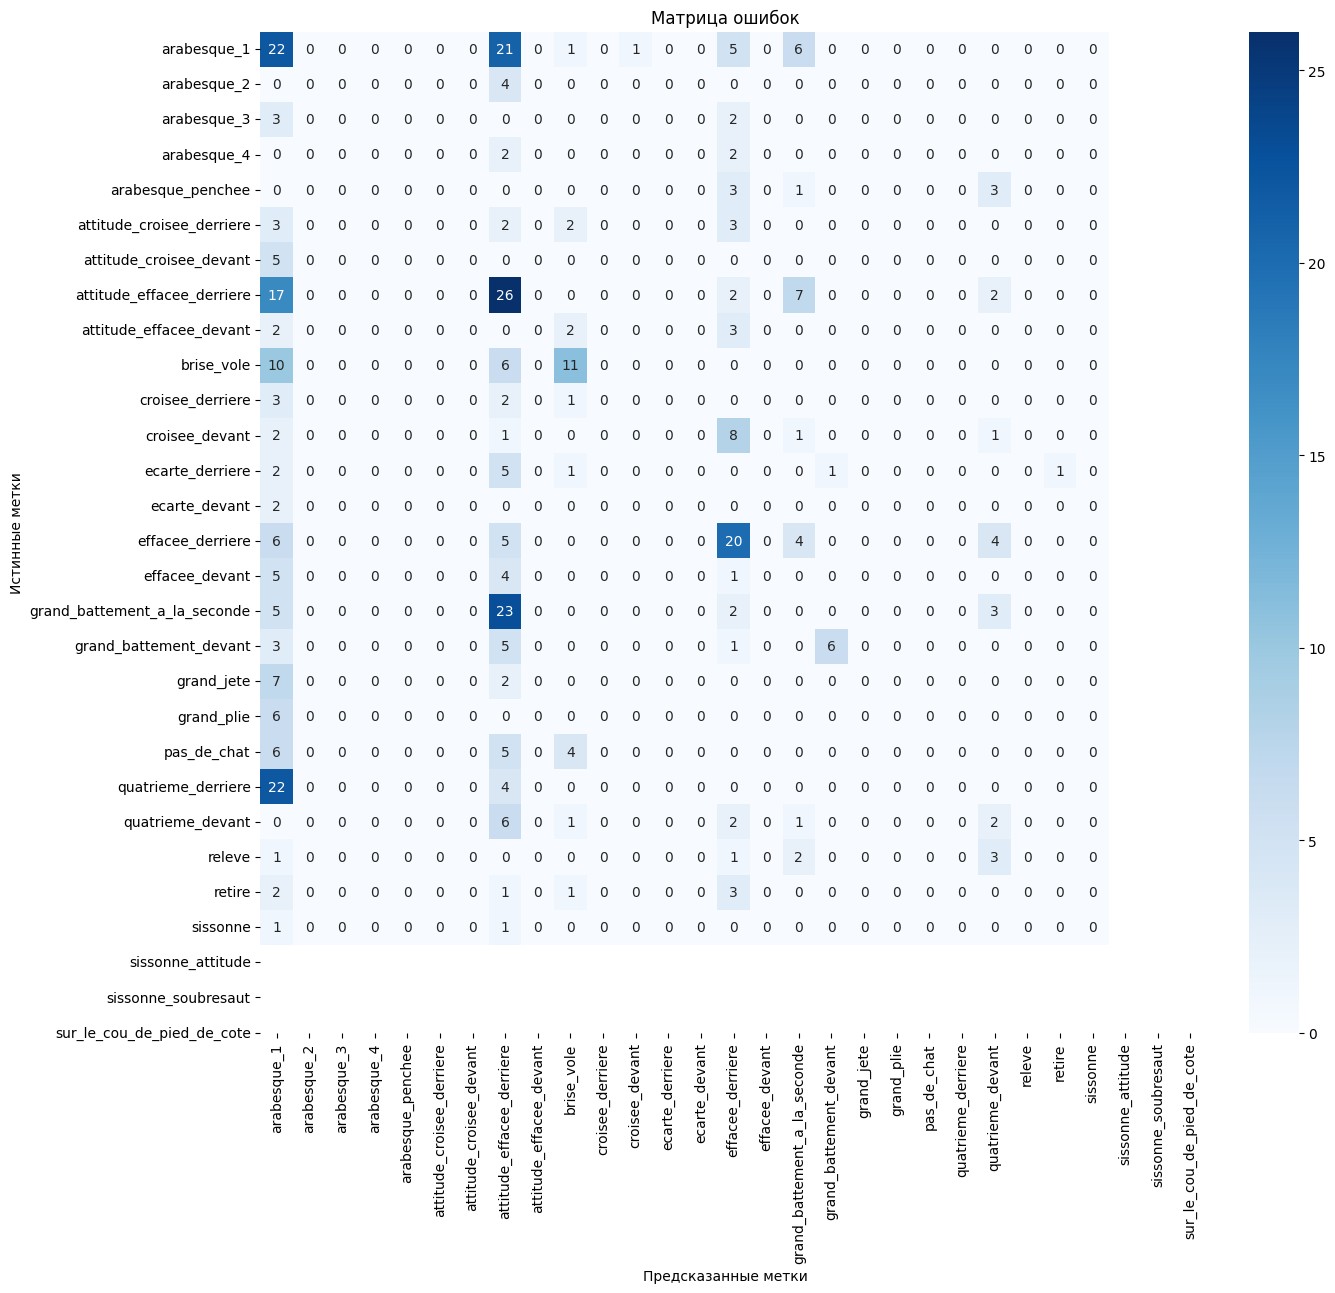

In [ ]:
# Матрица ошибок
conf_matrix_AdaBo = confusion_matrix(y_test_AdaBo, y_pred_AdaBo)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_AdaBo, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить KNeighborsClassifier

In [ ]:
X_train_KN, X_test_KN, y_train_KN, y_test_KN = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Инициализация и обучение модели
clf_KN = KNeighborsClassifier()
clf_KN.fit(X_train_KN, y_train_KN)

KNeighborsClassifier()

In [ ]:
# Предсказание на тестовой выборке
y_pred_KN = clf_KN.predict(X_test_KN)

In [ ]:
# Оценка точности
accuracy_KN = accuracy_score(y_test_KN, y_pred_KN)
print(f"Точность на тестовой выборке: {accuracy_KN:.2f}")

Точность на тестовой выборке: 0.48


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_KN, y_pred_KN))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.53      0.70      0.60        56
           1       0.00      0.00      0.00         4
           2       0.25      0.20      0.22         5
           3       0.50      0.25      0.33         4
           4       0.50      0.14      0.22         7
           5       0.33      0.30      0.32        10
           6       0.33      0.40      0.36         5
           7       0.48      0.37      0.42        54
           9       0.38      0.43      0.40         7
          10       0.56      0.56      0.56        27
          11       0.05      0.17      0.07         6
          13       0.17      0.08      0.11        13
          14       0.40      0.20      0.27        10
          15       0.00      0.00      0.00         2
          16       0.49      0.72      0.58        39
          17       0.50      0.10      0.17        10
          18       0.64      0.85      0.73        33
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Матрица ошибок
conf_matrix_KN = confusion_matrix(y_test_KN, y_pred_KN)
# print("Матрица ошибок:")
# print(conf_matrix_KN)

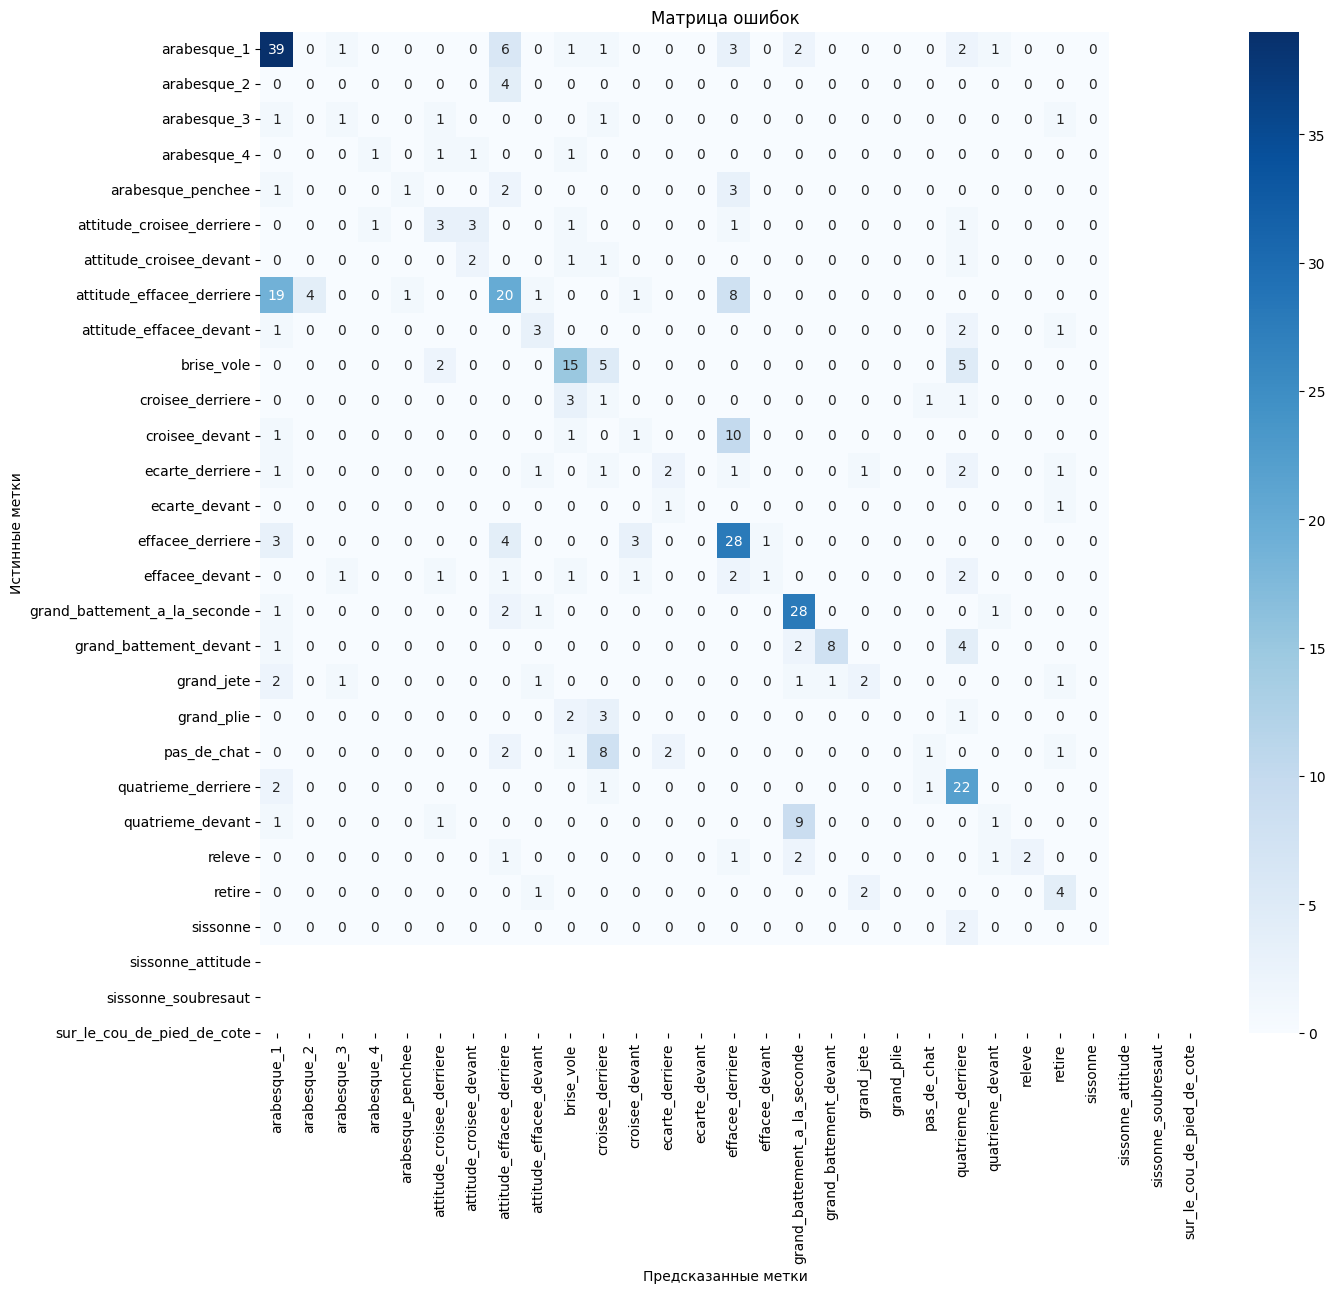

In [ ]:
# Матрица ошибок
conf_matrix_KN = confusion_matrix(y_test_KN, y_pred_KN)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_KN, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить GaussianNB

In [ ]:
X_train_GNB, X_test_GNB, y_train_GNB, y_test_GNB = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Инициализация и обучение модели
clf_GNB = GaussianNB()
clf_GNB.fit(X_train_GNB, y_train_GNB)

GaussianNB()

In [ ]:
# Предсказание на тестовой выборке
y_pred_GNB = clf_GNB.predict(X_test_GNB)

In [ ]:
# Оценка точности
accuracy_GNB = accuracy_score(y_test_GNB, y_pred_GNB)
print(f"Точность на тестовой выборке: {accuracy_GNB:.2f}")

Точность на тестовой выборке: 0.21


### Попробуем обучить GradientBoostingClassifier

In [ ]:
X_train_GBoo, X_test_GBoo, y_train_GBoo, y_test_GBoo = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Инициализация и обучение модели
# clf_GBoo = GradientBoostingClassifier()
clf_GBoo = GradientBoostingClassifier(n_estimators=100,
                                      learning_rate=1.0,
                                      max_depth=1,
                                      random_state=0)

clf_GBoo.fit(X_train_GBoo, y_train_GBoo)

GradientBoostingClassifier(learning_rate=1.0, max_depth=1, random_state=0)

In [ ]:
# Предсказание на тестовой выборке
y_pred_GBoo = clf_GBoo.predict(X_test_GBoo)

In [ ]:
# Оценка точности
accuracy_GBoo = accuracy_score(y_test_GBoo, y_pred_GBoo)
print(f"Точность на тестовой выборке: {accuracy_GBoo:.2f}")

Точность на тестовой выборке: 0.27


### Попробуем обучить ExtraTreesClassifier

In [ ]:
X_train_ExTree, X_test_ExTree, y_train_ExTree, y_test_ExTree = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.datasets import make_classification

X_train_ExTree, y_train_ExTree = make_classification(n_features=51,
                                                     random_state=42)
clf_ExTree = ExtraTreesClassifier(n_estimators=100,
                                  random_state=0)
clf_ExTree.fit(X_train_ExTree, y_train_ExTree)

ExtraTreesClassifier(random_state=0)

In [ ]:
# Предсказание на тестовой выборке
y_pred_ExTree = clf_ExTree.predict(X_test_ExTree)

In [ ]:
# Оценка точности
accuracy_ExTree = accuracy_score(y_test_ExTree, y_pred_ExTree)
print(f"Точность на тестовой выборке: {accuracy_ExTree:.2f}")

Точность на тестовой выборке: 0.01
